In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

## Dataset

In [2]:
x_raw = np.array([
    ["Pointy", "Round", "Present"],
    ["Floppy", "NotRound", "Present"],
    ["Floppy", "Round", "Absent"],
    ["Pointy", "NotRound", "Present"],
    ["Pointy", "Round", "Present"],
    ["Pointy", "Round", "Absent"],
    ["Floppy", "NotRound", "Absent"],
    ["Pointy", "Round", "Absent"],
    ["Floppy", "Round", "Absent"],
    ["Floppy", "Round", "Absent"]
])

# Target: 1 = Cat, 0 = Not Cat
y = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])

In [4]:
#one-hot encoding
encoder = OneHotEncoder(sparse_output=False)
x_encoded = encoder.fit_transform(x_raw)
print("Encoded feature names: ")
print(encoder.get_feature_names_out())

Encoded feature names: 
['x0_Floppy' 'x0_Pointy' 'x1_NotRound' 'x1_Round' 'x2_Absent' 'x2_Present']


## Model

In [5]:
rf = RandomForestClassifier(
    n_estimators = 10,
    max_depth = 2,
    criterion = "entropy",
    random_state = 42
)
rf.fit(x_encoded, y)

,n_estimators,10
,criterion,'entropy'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction

In [6]:
y_pred = rf.predict(x_encoded)
print("Accuracy: ", accuracy_score(y, y_pred))

Accuracy:  0.9


## Plot: Feature importance

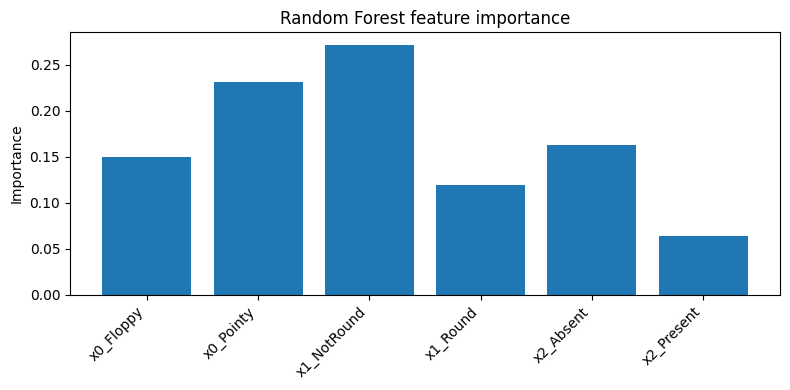

In [7]:
importances = rf.feature_importances_
feature_names = encoder.get_feature_names_out()
plt.figure(figsize = (8,4))
plt.bar(feature_names, importances)
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("Importance")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

## Prediction

In [8]:
new_animal = np.array([["Pointy", "Round", "Present"]])
new_animal_encoded = encoder.transform(new_animal)
print("Prediction: ", rf.predict(new_animal_encoded))

Prediction:  [1]
